# Parte 2 — EDA y Modelos Base
**Proyecto:** Analítica de Pádel 2026-1  
**Objetivo:** Explorar el dataset `data` generado en la Parte 1, identificar patrones relevantes y entrenar los modelos base (Regresión Logística, Ridge, Lasso) con validación cruzada estratificada y tuning de hiperparámetros.


## 0. Carga de librerías y datos


In [1]:
import subprocess, sys
result = subprocess.run([sys.executable, "-m", "pip", "show", "scikit-learn"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: 
Author: 
Author-email: 
License: 
Location: /home/byn/Workspace/analitica-de-datos/ad-proyecto-final/.venv/lib/python3.12/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.calibration import calibration_curve
import joblib


pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42


### Carga del dataset final
> Carga el archivo generado al final de la Parte 1 (`dataframe_final.pkl` o `.csv`).


In [71]:
# Cargar pkl o csv generado en la Parte 1
try:
    data = pd.read_pickle("dataframes/data_con_jugadores.pkl")
    print("Cargado desde pickle")
except FileNotFoundError:
    data = pd.read_csv("datafranes/data_con_jugadores.csv")
    print("Cargado desde CSV")

print(f"Shape: {data.shape}")
print(f"\nVariable objetivo — distribución:")
print(data["ganador_partido"].value_counts())
data.head()


Cargado desde pickle
Shape: (334, 97)

Variable objetivo — distribución:
ganador_partido
1    167
0    167
Name: count, dtype: int64


,partido,punto,cancha,perspectiva_equipo,jugador_1_equipo,jugador_2_equipo,jugador_1_rival,jugador_2_rival,duracion_punto,velocidad_prom_equipo,velocidad_prom_rival,velocidad_max_equipo,velocidad_max_rival,desplazamiento_equipo,desplazamiento_rival,dist_red_prom_equipo,dist_red_prom_rival,dist_companero_prom_equipo,dist_companero_prom_rival,hits_equipo,hits_rival,aceleracion_prom_equipo,aceleracion_prom_rival,velocidad_prom_pelota,velocidad_max_pelota,marcador_equipo,marcador_rival,gano_punto,ganador_partido,vel_prom_acum_equipo,vel_prom_acum_rival,vel_max_acum_equipo,vel_max_acum_rival,desplaz_acum_equipo,desplaz_acum_rival,hits_acum_equipo,hits_acum_rival,acel_prom_acum_equipo,acel_prom_acum_rival,dist_red_acum_equipo,dist_red_acum_rival,dist_comp_acum_equipo,dist_comp_acum_rival,win_rate_acum_equipo,racha_ultimos3_equipo,racha_ultimos3_rival,diferencia_marcador,vel_pelota_acum,es_primer_punto,edad_jugador_1_equipo,genero_jugador_1_equipo,experiencia_padel_jugador_1_equipo,tiempo_jugando_padel_jugador_1_equipo,practica_otro_deporte_raqueta_jugador_1_equipo,nivel_actual_padel_jugador_1_equipo,estado_fisico_jugador_1_equipo,frecuencia_deporte_jugador_1_equipo,estatura_jugador_1_equipo,talla_jugador_1_equipo,lesiones_ly_jugador_1_equipo,clases_padel_jugador_1_equipo,edad_jugador_2_equipo,genero_jugador_2_equipo,experiencia_padel_jugador_2_equipo,tiempo_jugando_padel_jugador_2_equipo,practica_otro_deporte_raqueta_jugador_2_equipo,nivel_actual_padel_jugador_2_equipo,estado_fisico_jugador_2_equipo,frecuencia_deporte_jugador_2_equipo,estatura_jugador_2_equipo,talla_jugador_2_equipo,lesiones_ly_jugador_2_equipo,clases_padel_jugador_2_equipo,edad_jugador_1_rival,genero_jugador_1_rival,experiencia_padel_jugador_1_rival,tiempo_jugando_padel_jugador_1_rival,practica_otro_deporte_raqueta_jugador_1_rival,nivel_actual_padel_jugador_1_rival,estado_fisico_jugador_1_rival,frecuencia_deporte_jugador_1_rival,estatura_jugador_1_rival,talla_jugador_1_rival,lesiones_ly_jugador_1_rival,clases_padel_jugador_1_rival,edad_jugador_2_rival,genero_jugador_2_rival,experiencia_padel_jugador_2_rival,tiempo_jugando_padel_jugador_2_rival,practica_otro_deporte_raqueta_jugador_2_rival,nivel_actual_padel_jugador_2_rival,estado_fisico_jugador_2_rival,frecuencia_deporte_jugador_2_rival,estatura_jugador_2_rival,talla_jugador_2_rival,lesiones_ly_jugador_2_rival,clases_padel_jugador_2_rival
0,1,1,1,1,Alejandra Salazar Galeano,Angel Santiago Toribio Godoy,Santiago Pena Beltran,Sahily Andrea Herrera Eljadue,5.26666666666667,0.448899,0.304600,3.394113,1.697056,2.319310,3.167838,7.085018,5.531054,3.880469,4.203185,3,0,1.146037e-17,0.032051,1.313236,50.0,1,0,1,1,0.426848,0.413807,7.000000,7.000000,0.000000,0.000000,0.0,0.0,-1.081373e-04,0.037803,6.978336,5.409319,3.955897,3.950549,0.000000,0.0,0.0,1,0.000000,1,19.0,Femenino,0.0,0.0,0.0,0.0,1.0,1.0,158.0,49.0,0.0,1.0,18.0,Masculino,0.0,0.0,1.0,0.0,1.0,3.0,176.0,56.0,0.0,2.0,19.0,Masculino,1.0,0.0,1.0,1.0,1.0,2.0,176.0,80.0,1.0,2.0,18.0,Femenino,0.0,0.0,0.0,0.0,1.0,0.0,160.0,47.0,0.0,1.0
1,1,2,1,1,Alejandra Salazar Galeano,Angel Santiago Toribio Godoy,Santiago Pena Beltran,Sahily Andrea Herrera Eljadue,9.5,0.444245,0.846178,7.000000,7.000000,3.810193,68.174869,6.839614,5.309570,5.502391,3.937636,3,7,4.119088e-15,0.054745,1.796484,50.0,2,0,1,1,0.448899,0.304600,3.394113,1.697056,2.319310,3.167838,3.0,0.0,1.146037e-17,0.032051,7.085018,5.531054,3.880469,4.203185,1.000000,1.0,0.0,2,1.313236,0,19.0,Femenino,0.0,0.0,0.0,0.0,1.0,1.0,158.0,49.0,0.0,1.0,18.0,Masculino,0.0,0.0,1.0,0.0,1.0,3.0,176.0,56.0,0.0,2.0,19.0,Masculino,1.0,0.0,1.0,1.0,1.0,2.0,176.0,80.0,1.0,2.0,18.0,Femenino,0.0,0.0,0.0,0.0,1.0,0.0,160.0,47.0,0.0,1.0
2,1,3,1,1,Alejandra Salazar Galeano,Angel Santiago Toribio Godoy,Santiago Pena Beltran,Sahily Andrea Herrera Eljadue,4.6,0.138279,0.205893,1.697056,1.697056,0.622254,1.866762,7.058436,5.432353,3.176596,3.379986,2,2,-7.407407e-02,0.036765,1.173509,50.0,2,1,0,1,0.446572,0.575389,7.000000,7.000000,6.129504,71.342707

---
## 1. Análisis Exploratorio de Datos (EDA)


### 1.1 Vista general del dataset


In [4]:
print("Shape:", data.shape)
print("\nTipos de datos:")
print(data.dtypes.value_counts())
print("\nEstadísticas descriptivas:")
data.describe().round(3)


Shape: (334, 97)

Tipos de datos:
float64    76
int64      12
str         8
object      1
Name: count, dtype: int64

Estadísticas descriptivas:


,partido,punto,cancha,perspectiva_equipo,velocidad_prom_equipo,velocidad_prom_rival,velocidad_max_equipo,velocidad_max_rival,desplazamiento_equipo,desplazamiento_rival,dist_red_prom_equipo,dist_red_prom_rival,dist_companero_prom_equipo,dist_companero_prom_rival,hits_equipo,hits_rival,aceleracion_prom_equipo,aceleracion_prom_rival,velocidad_prom_pelota,velocidad_max_pelota,marcador_equipo,marcador_rival,gano_punto,ganador_partido,vel_prom_acum_equipo,vel_prom_acum_rival,vel_max_acum_equipo,vel_max_acum_rival,desplaz_acum_equipo,desplaz_acum_rival,hits_acum_equipo,hits_acum_rival,acel_prom_acum_equipo,acel_prom_acum_rival,dist_red_acum_equipo,dist_red_acum_rival,dist_comp_acum_equipo,dist_comp_acum_rival,win_rate_acum_equipo,racha_ultimos3_equipo,racha_ultimos3_rival,diferencia_marcador,vel_pelota_acum,es_primer_punto,edad_jugador_1_equipo,experiencia_padel_jugador_1_equipo,tiempo_jugando_padel_jugador_1_equipo,practica_otro_deporte_raqueta_jugador_1_equipo,nivel_actual_padel_jugador_1_equipo,estado_fisico_jugador_1_equipo,frecuencia_deporte_jugador_1_equipo,estatura_jugador_1_equipo,talla_jugador_1_equipo,lesiones_ly_jugador_1_equipo,clases_padel_jugador_1_equipo,edad_jugador_2_equipo,experiencia_padel_jugador_2_equipo,tiempo_jugando_padel_jugador_2_equipo,practica_otro_deporte_raqueta_jugador_2_equipo,nivel_actual_padel_jugador_2_equipo,estado_fisico_jugador_2_equipo,frecuencia_deporte_jugador_2_equipo,estatura_jugador_2_equipo,talla_jugador_2_equipo,lesiones_ly_jugador_2_equipo,clases_padel_jugador_2_equipo,edad_jugador_1_rival,experiencia_padel_jugador_1_rival,tiempo_jugando_padel_jugador_1_rival,practica_otro_deporte_raqueta_jugador_1_rival,nivel_actual_padel_jugador_1_rival,estado_fisico_jugador_1_rival,frecuencia_deporte_jugador_1_rival,estatura_jugador_1_rival,talla_jugador_1_rival,lesiones_ly_jugador_1_rival,clases_padel_jugador_1_rival,edad_jugador_2_rival,experiencia_padel_jugador_2_rival,tiempo_jugando_padel_jugador_2_rival,practica_otro_deporte_raqueta_jugador_2_rival,nivel_actual_padel_jugador_2_rival,estado_fisico_jugador_2_rival,frecuencia_deporte_jugador_2_rival,estatura_jugador_2_rival,talla_jugador_2_rival,lesiones_ly_jugador_2_rival,clases_padel_jugador_2_rival
count,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000,334.000
mean,16.551,5.491,1.389,1.500,0.620,0.620,6.480,6.480,17.175,17.175,6.370,6.370,5.275,5.275,3.219,3.219,-0.001,-0.001,1.748,47.192,2.775,2.775,0.500,0.500,0.621,0.621,6.957,6.957,77.001,77.001,14.458,14.458,-0.014,-0.014,6.421,6.421,5.148,5.148,0.449,1.195,1.195,0.000,1.543,0.102,20.096,0.350,0.374,0.814,0.647,1.856,1.778,172.698,65.326,0.249,1.177,18.823,0.141,0.237,0.716,0.320,1.793,1.772,172.129,64.467,0.257,1.263,20.096,0.350,0.374,0.814,0.647,1.856,1.778,172.698,65.326,0.249,1.177,18.823,0.141,0.237,0.716,0.320,1.793,1.772,172.129,64.467,0.257,1.263
std,11.809,2.961,0.488,0.501,0.377,0.377,1.373,1.373,20.995,20.995,1.260,1.260,1.656,1.656,4.742,4.742,0.100,0.100,1.048,9.909,1.991,1.991,0.501,0.501,0.277,0.277,0.402,0.402,86.297,86.297,15.893,15.893,0.092,0.092,1.105,1.105,1.383,1.383,0.321,0.999,0.999,2.595,0.871,0.303,3.051,0.478,0.715,0.389,0.681,0.687,1.051,7.889,10.272,0.433,0.672,1.221,0.348,0.591,0.452,0.622,0.799,1.044,5.920,8.441,0.438,0.636,3.051,0.478,0.715,0.389,0.681,0.687,1.051,7.889,10.272,0.433,0.672,1.221,0.348,0.591,0.452,0.622,0.799,

In [5]:
# Nulos residuales
nulos = data.isnull().sum()
print("Columnas con nulos:", (nulos > 0).sum())
if (nulos > 0).any():
    print(nulos[nulos > 0])
else:
    print("Sin valores nulos — dataset limpio.")


Columnas con nulos: 0
Sin valores nulos — dataset limpio.


### 1.2 Variable objetivo — `EQUIPO_GANADOR`


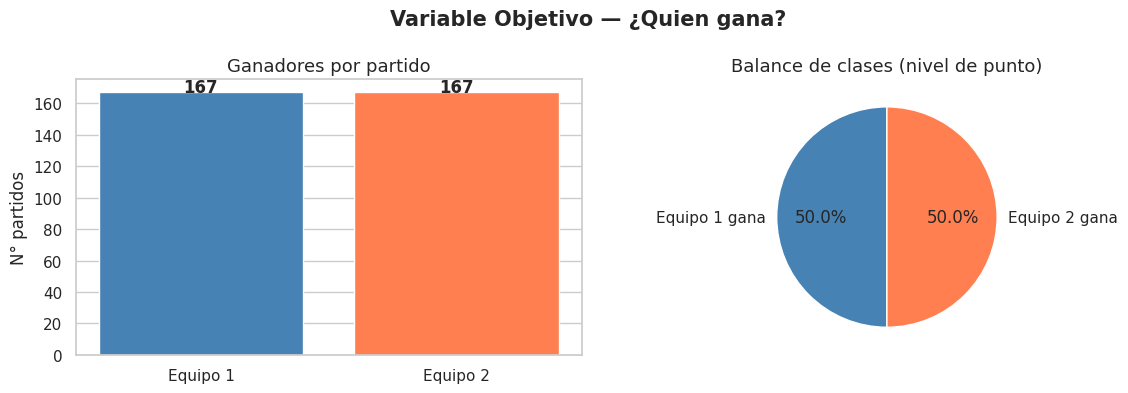


Distribución clase objetivo:
gano_punto
0    167
1    167
Name: count, dtype: int64
Balance: 50.0% / 50.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ganadores por partido
ganador_partido = data["ganador_partido"].value_counts().sort_index()
axes[0].bar(["Equipo 1", "Equipo 2"], ganador_partido.values, color=["steelblue", "coral"])
axes[0].set_title("Ganadores por partido", fontsize=13)
axes[0].set_ylabel("N° partidos")
for i, v in enumerate(ganador_partido.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# Balance de clases (puntos)
dist_puntos = data["gano_punto"].value_counts().sort_index()
axes[1].pie(dist_puntos.values, labels=["Equipo 1 gana", "Equipo 2 gana"],
            autopct="%1.1f%%", colors=["steelblue", "coral"], startangle=90)
axes[1].set_title("Balance de clases (nivel de punto)", fontsize=13)

plt.suptitle("Variable Objetivo — ¿Quien gana? ", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nDistribución clase objetivo:")
print(dist_puntos)
print(f"Balance: {dist_puntos.min()/dist_puntos.sum()*100:.1f}% / {dist_puntos.max()/dist_puntos.sum()*100:.1f}%")


### 1.3 Variables de marcador y contexto


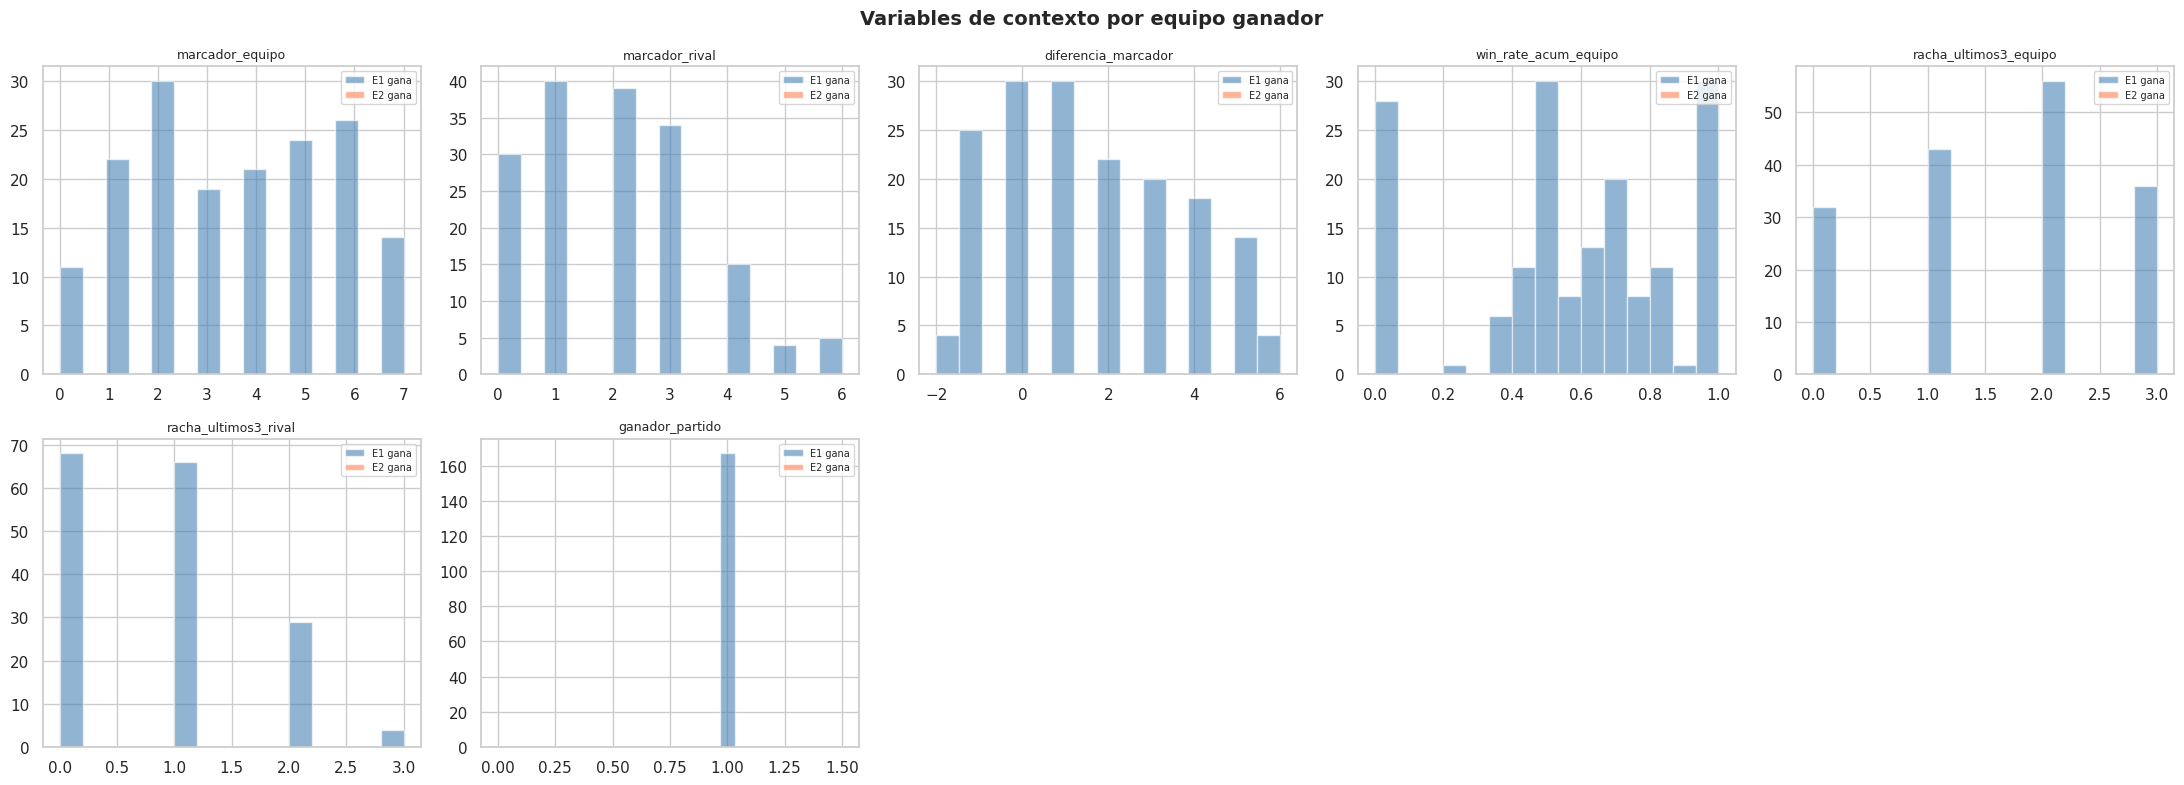

In [13]:
vars_contexto = [
    "marcador_equipo",
    "marcador_rival",
    "diferencia_marcador",
    "win_rate_acum_equipo",
    "racha_ultimos3_equipo",
    "racha_ultimos3_rival",
    "ganador_partido"
]
# Filtrar solo las que existen en el dataframe
vars_contexto = [v for v in vars_contexto if v in data.columns]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, var in enumerate(vars_contexto):
    for eq, color in [(1, "steelblue"), (2, "coral")]:
        subset = data[data["ganador_partido"] == eq][var]
        axes[i].hist(subset, alpha=0.6, color=color, label=f"E{eq} gana", bins=15)
    axes[i].set_title(var, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(len(vars_contexto), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variables de contexto por equipo ganador", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.4 Variables de tracking (video)


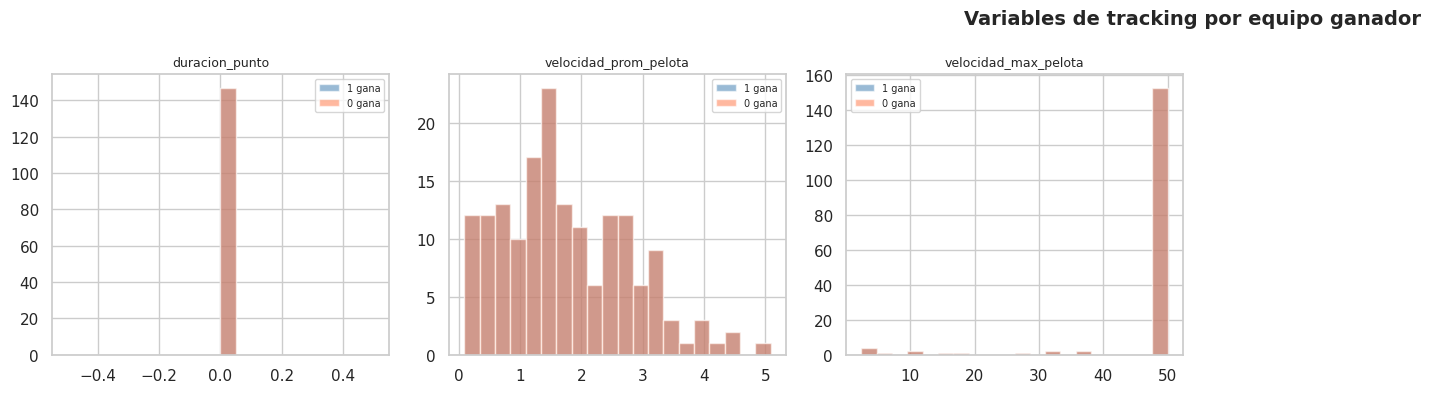

In [18]:
vars_tracking = [
    "duracion_punto",
    "velocidad_prom_e1", "velocidad_prom_e2",
    "velocidad_max_e1", "velocidad_max_e2",
    "desplazamiento_total_e1", "desplazamiento_total_e2",
    "dist_red_prom_e1", "dist_red_prom_e2",
    "dist_companero_prom_e1", "dist_companero_prom_e2",
    "hits_e1", "hits_e2",
    "velocidad_prom_pelota", "velocidad_max_pelota",
    "aceleracion_prom_e1", "aceleracion_prom_e2"
]

# Mantener solo columnas existentes
vars_tracking = [v for v in vars_tracking if v in data.columns]

# ------------------------------------------------------------
# Convertir duración a segundos si existe
# ------------------------------------------------------------
if "duracion_punto" in data.columns:
    data["duracion_punto"] = pd.to_timedelta(
        data["duracion_punto"],
        errors="coerce"
    ).dt.total_seconds()

# ------------------------------------------------------------
# Mantener únicamente variables numéricas
# ------------------------------------------------------------
vars_tracking = [
    v for v in vars_tracking
    if pd.api.types.is_numeric_dtype(data[v])
]

# ------------------------------------------------------------
# Gráficas
# ------------------------------------------------------------
n_cols = 6
n_rows = -(-len(vars_tracking) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 4))
axes = axes.flatten()

for i, var in enumerate(vars_tracking):

    for eq, color in [(1, "steelblue"), (0, "coral")]:
        subset = data.loc[data["ganador_partido"] == eq, var].dropna()

        axes[i].hist(
            subset,
            alpha=0.55,
            color=color,
            label=f"{eq} gana",
            bins=20
        )

    axes[i].set_title(var, fontsize=9)
    axes[i].legend(fontsize=7)

# Ocultar ejes vacíos
for j in range(len(vars_tracking), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Variables de tracking por equipo ganador",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

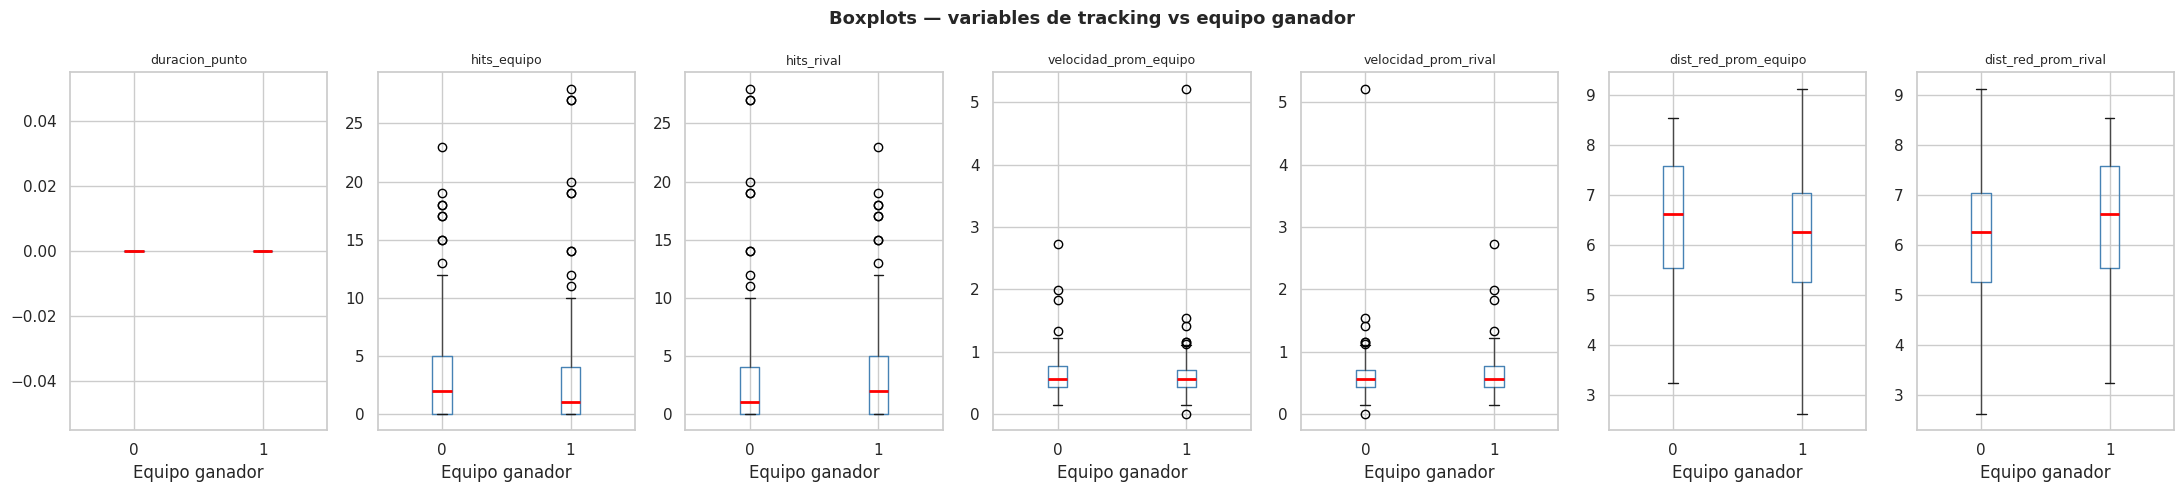

In [20]:
# Boxplots comparativos — variables de tracking clave
vars_box = [v for v in [
    "duracion_punto",
    "hits_equipo",
    "hits_rival",
    "velocidad_prom_equipo",
    "velocidad_prom_rival",
    "dist_red_prom_equipo",
    "dist_red_prom_rival"
] if v in data.columns]

fig, axes = plt.subplots(1, len(vars_box), figsize=(22, 5))
if len(vars_box) == 1:
    axes = [axes]

for i, var in enumerate(vars_box):
    data.boxplot(column=var, by="ganador_partido", ax=axes[i],
                 boxprops=dict(color="steelblue"),
                 medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(var, fontsize=9)
    axes[i].set_xlabel("Equipo ganador")

plt.suptitle("Boxplots — variables de tracking vs equipo ganador", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [21]:
# Medias por equipo ganador — tracking
print("Medias de variables de tracking por equipo ganador:")
data.groupby("ganador_partido")[vars_tracking].mean().round(3)


Medias de variables de tracking por equipo ganador:


,duracion_punto,velocidad_prom_pelota,velocidad_max_pelota
ganador_partido,,,
0,0.0,1.748,47.192
1,0.0,1.748,47.192


### 1.5 Matriz de correlaciones


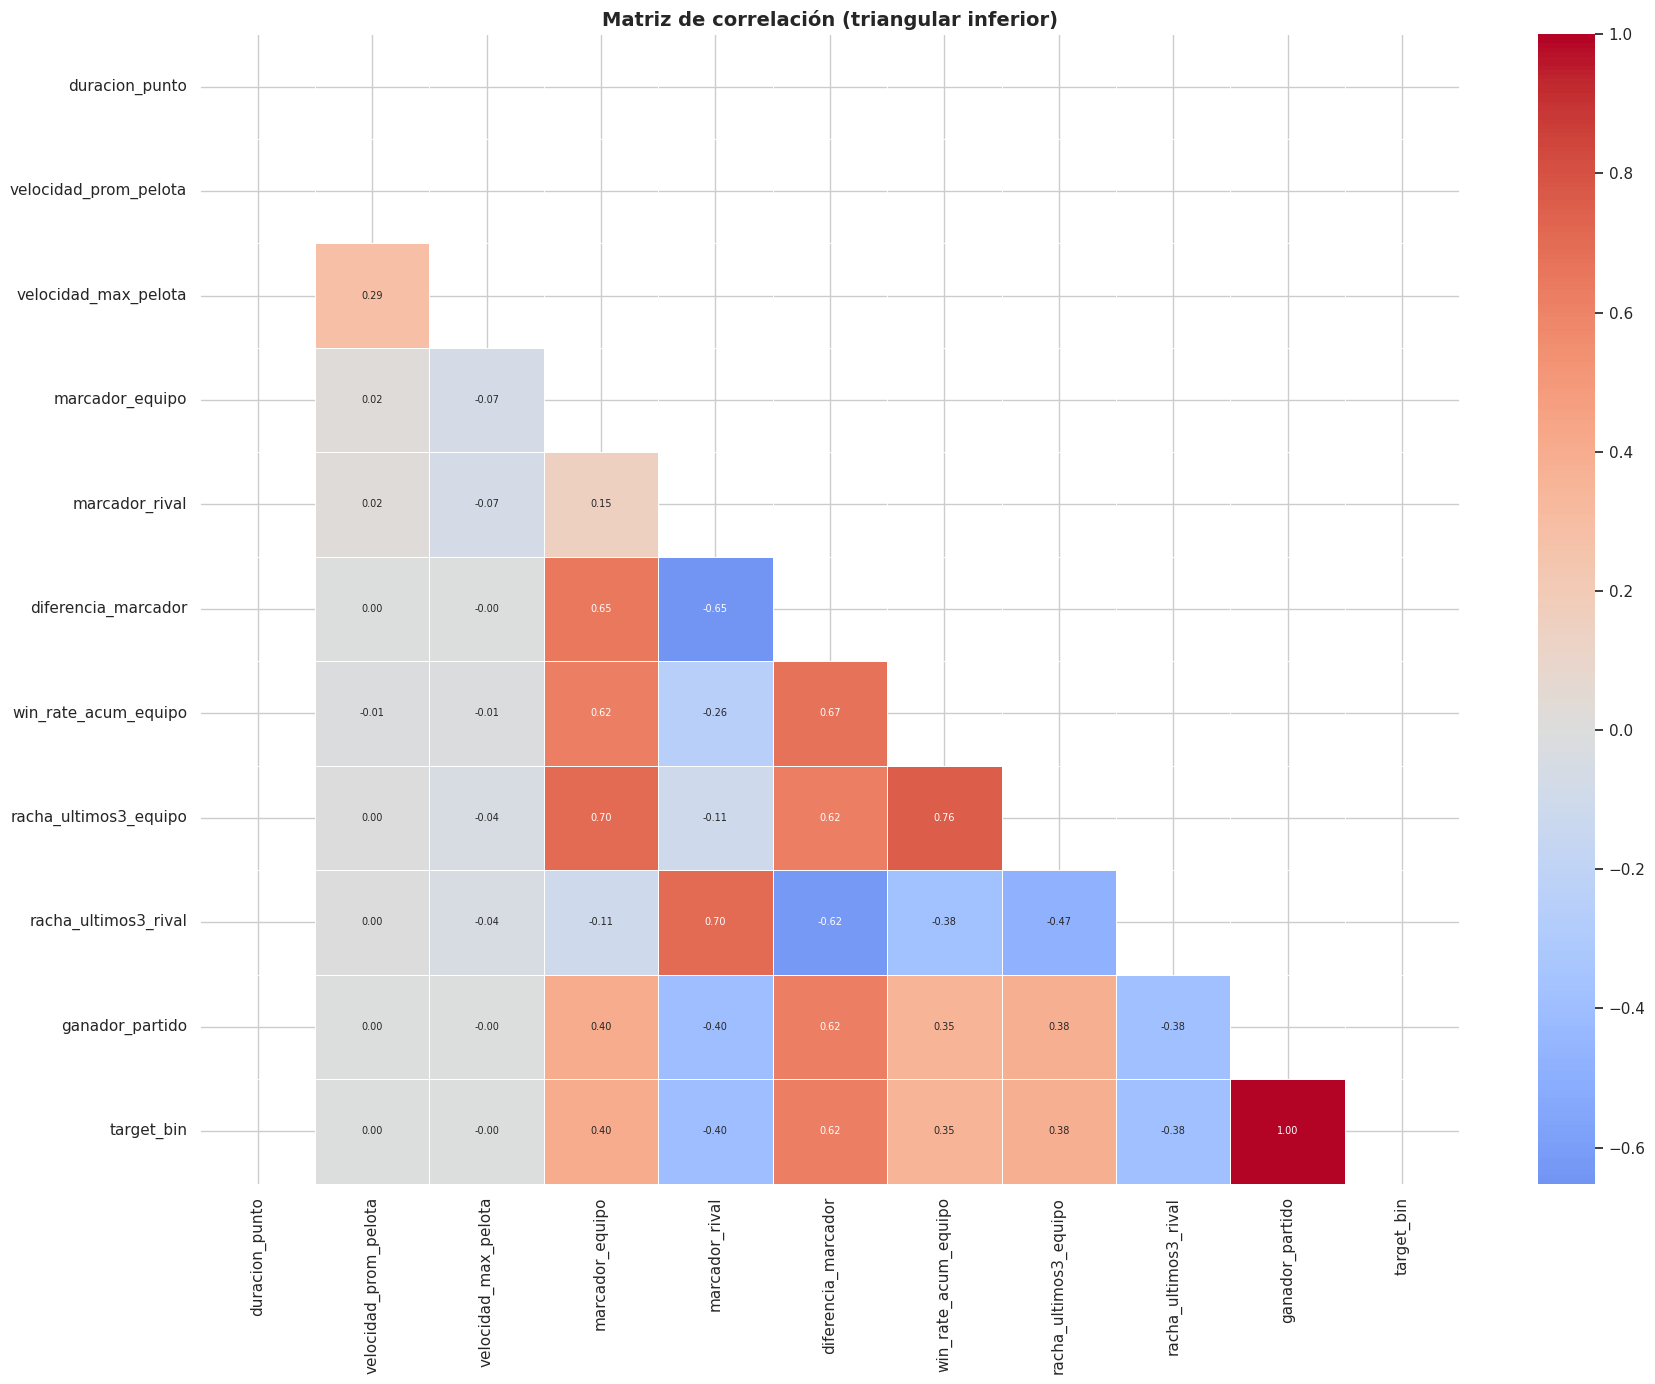

In [36]:
# Crear variable binaria para correlación
data_num = data.copy()
data_num["target_bin"] = (data_num["ganador_partido"] == 1).astype(int)

vars_modelo = [v for v in vars_tracking + vars_contexto if v in data_num.columns]

corr = data_num[vars_modelo + ["target_bin"]].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Matriz de correlación (triangular inferior)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [38]:
# ------------------------------------------------------------
# Preparar datos numéricos
# ------------------------------------------------------------

df_corr = data.copy()

# Convertir duración a segundos
if "duracion_punto" in df_corr.columns:

    df_corr["duracion_punto"] = pd.to_timedelta(
        df_corr["duracion_punto"],
        errors="coerce"
    ).dt.total_seconds()

# ------------------------------------------------------------
# Variables numéricas
# ------------------------------------------------------------

numeric_cols = df_corr.select_dtypes(
    include=["float64", "int64", "float32", "int32"]
).columns

# ------------------------------------------------------------
# Matriz de correlación
# ------------------------------------------------------------

corr = df_corr[numeric_cols].corr()

# ------------------------------------------------------------
# Correlación con la variable objetivo
# ------------------------------------------------------------

corr_target = (
    corr["ganador_partido"]
    .drop("ganador_partido")
    .abs()
    .sort_values(ascending=False)
)

print("Top 15 variables más correlacionadas con ganador_partido:")

print(
    corr_target.head(15).to_string()
)

Top 15 variables más correlacionadas con ganador_partido:
diferencia_marcador                               0.617092
marcador_rival                                    0.402092
marcador_equipo                                   0.402092
racha_ultimos3_rival                              0.381182
racha_ultimos3_equipo                             0.381182
win_rate_acum_equipo                              0.353924
gano_punto                                        0.353293
edad_jugador_1_rival                              0.310604
edad_jugador_1_equipo                             0.310604
edad_jugador_2_rival                              0.262734
edad_jugador_2_equipo                             0.262734
practica_otro_deporte_raqueta_jugador_2_rival     0.245551
practica_otro_deporte_raqueta_jugador_2_equipo    0.245551
nivel_actual_padel_jugador_2_rival                0.236318
nivel_actual_padel_jugador_2_equipo               0.236318


### 1.6 Evolución del marcador a lo largo del partido


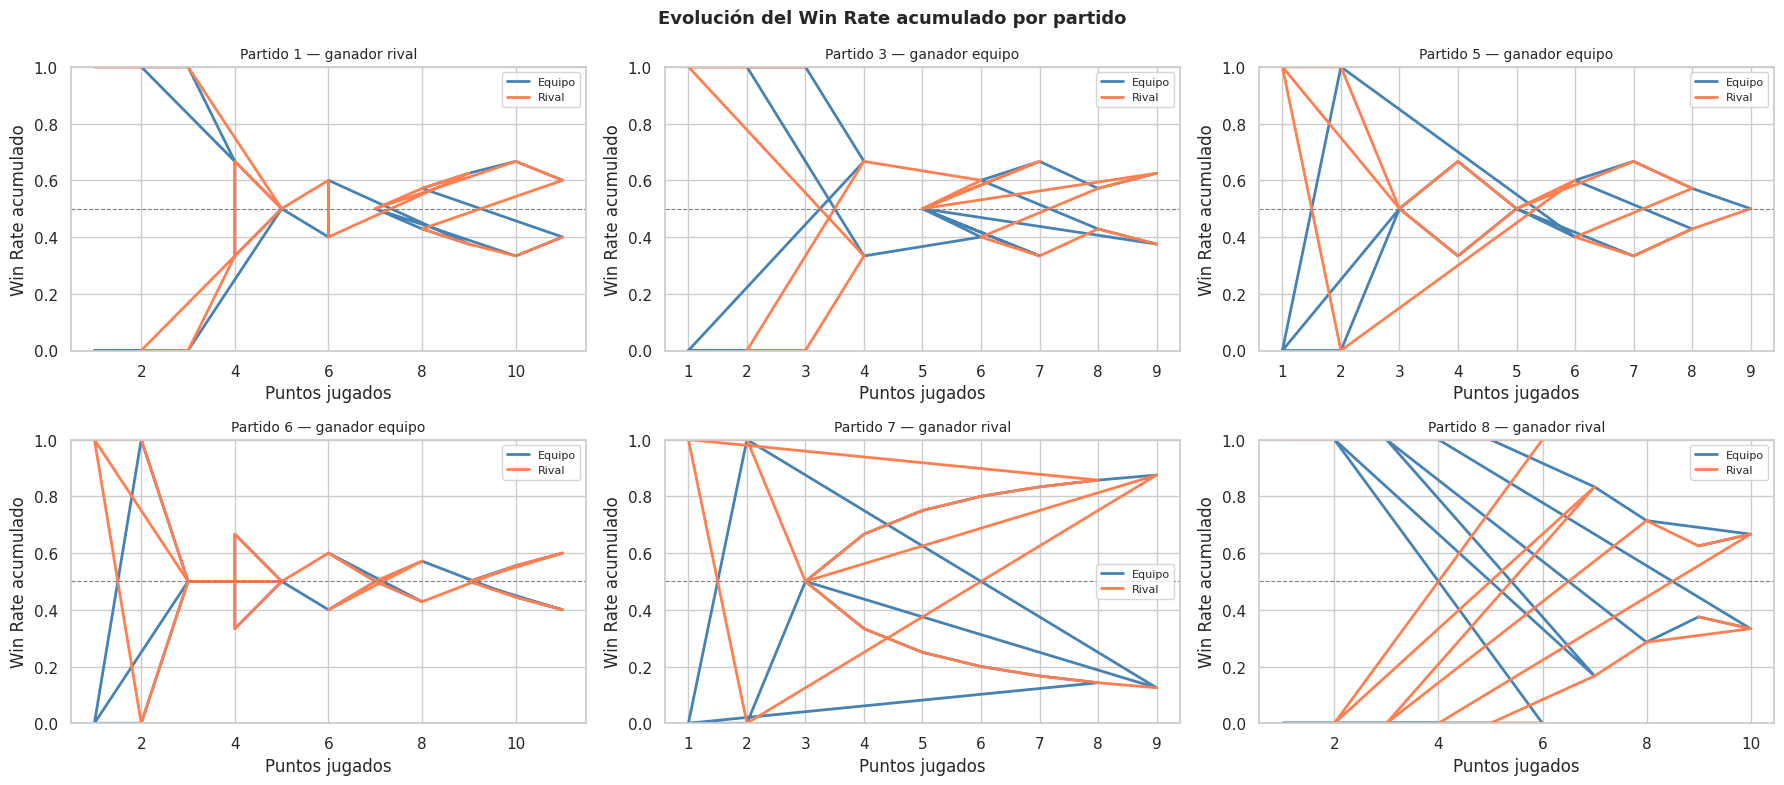

In [39]:
# Win Rate acumulado por partido (muestra los primeros 6 partidos)

partidos_muestra = sorted(data["partido"].unique())[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, pid in enumerate(partidos_muestra):

    sub = (
        data[data["partido"] == pid]
        .sort_values("marcador_equipo")
    )

    ganador = sub["ganador_partido"].iloc[0]

    axes[i].plot(
        sub["marcador_equipo"] + sub["marcador_rival"],
        sub["win_rate_acum_equipo"],
        label="Equipo",
        color="steelblue",
        linewidth=2
    )

    # Win rate del rival derivado
    axes[i].plot(
        sub["marcador_equipo"] + sub["marcador_rival"],
        1 - sub["win_rate_acum_equipo"],
        label="Rival",
        color="coral",
        linewidth=2
    )

    axes[i].axhline(
        0.5,
        color="gray",
        linestyle="--",
        linewidth=0.8
    )

    axes[i].set_title(
        f"Partido {pid} — ganador {'equipo' if ganador == 1 else 'rival'}",
        fontsize=10
    )

    axes[i].set_xlabel("Puntos jugados")
    axes[i].set_ylabel("Win Rate acumulado")

    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, 1)

plt.suptitle(
    "Evolución del Win Rate acumulado por partido",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

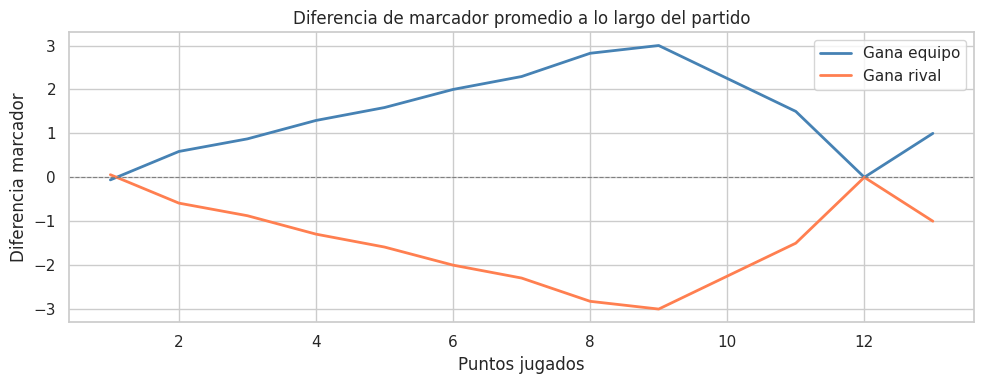

In [40]:
# Diferencia de marcador promedio vs puntos jugados

fig, ax = plt.subplots(figsize=(10, 4))

for eq, color, label in [
    (1, "steelblue", "Gana equipo"),
    (0, "coral", "Gana rival")
]:

    sub = data[data["ganador_partido"] == eq].copy()

    # puntos jugados acumulados
    sub["puntos_jugados"] = (
        sub["marcador_equipo"] +
        sub["marcador_rival"]
    )

    media_diff = (
        sub.groupby("puntos_jugados")["diferencia_marcador"]
        .mean()
    )

    ax.plot(
        media_diff.index,
        media_diff.values,
        color=color,
        label=label,
        linewidth=2
    )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8
)

ax.set_title(
    "Diferencia de marcador promedio a lo largo del partido",
    fontsize=12
)

ax.set_xlabel("Puntos jugados")
ax.set_ylabel("Diferencia marcador")

ax.legend()

plt.tight_layout()
plt.show()

---
## 2. Preparación del dataset para modelado


### 2.1 Selección de features y variable objetivo

Se usan las variables numéricas de tracking y contexto. Las columnas de identificación de jugadores (nombres) se excluyen del modelo base.


In [49]:
# Columnas a excluir del modelo
cols_excluir = [

    # Variable objetivo
    "ganador_partido",

    # Identificadores
    "partido",
    "punto",

    # Contexto administrativo
    "cancha",

    # Variables categóricas / texto
    "jugador_1_equipo",
    "jugador_2_equipo",
    "jugador_1_rival",
    "jugador_2_rival",

    # Variables categóricas adicionales
    "genero_jugador_1_equipo",
    "genero_jugador_2_equipo",
    "genero_jugador_1_rival",
    "genero_jugador_2_rival",

    # Duración sigue siendo object en muchos casos
    "duracion_punto"
]

feature_cols = [

    c for c in data.columns

    if c not in cols_excluir
    and data[c].dtype in [
        "float64",
        "int64",
        "float32",
        "int32"
    ]
]

print(f"Features seleccionadas ({len(feature_cols)}):")
print(feature_cols)

# ------------------------------------------------------------
# Matriz de features y target
# ------------------------------------------------------------
X = data[feature_cols].copy()

# 1 = gana equipo observado
# 0 = gana rival
y = data["ganador_partido"].astype(int)

print(f"\nShape X: {X.shape}")

print(
    f"Balance clases — "
    f"Equipo gana: {y.mean()*100:.1f}% | "
    f"Rival gana: {(1-y.mean())*100:.1f}%"
)

Features seleccionadas (84):
['perspectiva_equipo', 'velocidad_prom_equipo', 'velocidad_prom_rival', 'velocidad_max_equipo', 'velocidad_max_rival', 'desplazamiento_equipo', 'desplazamiento_rival', 'dist_red_prom_equipo', 'dist_red_prom_rival', 'dist_companero_prom_equipo', 'dist_companero_prom_rival', 'hits_equipo', 'hits_rival', 'aceleracion_prom_equipo', 'aceleracion_prom_rival', 'velocidad_prom_pelota', 'velocidad_max_pelota', 'marcador_equipo', 'marcador_rival', 'gano_punto', 'vel_prom_acum_equipo', 'vel_prom_acum_rival', 'vel_max_acum_equipo', 'vel_max_acum_rival', 'desplaz_acum_equipo', 'desplaz_acum_rival', 'hits_acum_equipo', 'hits_acum_rival', 'acel_prom_acum_equipo', 'acel_prom_acum_rival', 'dist_red_acum_equipo', 'dist_red_acum_rival', 'dist_comp_acum_equipo', 'dist_comp_acum_rival', 'win_rate_acum_equipo', 'racha_ultimos3_equipo', 'racha_ultimos3_rival', 'diferencia_marcador', 'vel_pelota_acum', 'es_primer_punto', 'edad_jugador_1_equipo', 'experiencia_padel_jugador_1_equipo

### 2.2 Estrategia de validación — Stratified K-Fold


In [50]:
# Validación cruzada estratificada 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluar_modelo(modelo, X, y, cv, nombre):
    """
    Evalúa un modelo con CV estratificada.
    Retorna dict con métricas y probabilidades OOF.
    """
    y_prob = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba")[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    resultados = {
        "Modelo":       nombre,
        "AUC":          round(roc_auc_score(y, y_prob), 4),
        "Log Loss":     round(log_loss(y, y_prob), 4),
        "Brier Score":  round(brier_score_loss(y, y_prob), 4),
        "Accuracy":     round(accuracy_score(y, y_pred), 4),
    }
    return resultados, y_prob

resultados_modelos = []
probs_modelos      = {}


---
## 3. Modelos Base


### 3.1 Preprocesamiento — StandardScaler


In [51]:
# Verificar escalado (se aplica dentro de cada Pipeline)
scaler_test = StandardScaler()
X_test_scaled = scaler_test.fit_transform(X)
print("Escalado OK — media aprox 0:", X_test_scaled.mean(axis=0).round(2)[:5])
print("Desv est aprox 1:", X_test_scaled.std(axis=0).round(2)[:5])


Escalado OK — media aprox 0: [ 0. -0. -0. -0.  0.]
Desv est aprox 1: [1. 1. 1. 1. 1.]


### 3.2 Regresión Logística (L2 — baseline)

**Tuning:** Se explora el parámetro `C` (inverso de la fuerza de regularización L2) con `GridSearchCV` optimizando AUC.


In [52]:
# Diagnóstico
print("NaN por columna:")
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"\nTotal filas con NaN: {X.isnull().any(axis=1).sum()}")

# Imputar con la mediana de cada columna
X = X.fillna(X.median())

print("NaN después de imputar:", X.isnull().sum().sum())

NaN por columna:
Series([], dtype: int64)

Total filas con NaN: 0
NaN después de imputar: 0


In [53]:
param_grid_lr = {
    "clf__C":        [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    "clf__penalty":  ["l2"],
    "clf__solver":   ["lbfgs"],
    "clf__max_iter": [1000],
}

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
])

gs_lr = GridSearchCV(
    pipeline_lr, param_grid_lr, cv=cv,
    scoring="roc_auc", n_jobs=-1, refit=True, verbose=1
)
gs_lr.fit(X, y)

print("\nMejores hiperparámetros — Regresión Logística:")
print(gs_lr.best_params_)
print(f"Mejor AUC CV: {gs_lr.best_score_:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits



Mejores hiperparámetros — Regresión Logística:
{'clf__C': 5.0, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Mejor AUC CV: 1.0000


In [54]:
# Evaluar mejor modelo LR
mejor_lr = gs_lr.best_estimator_
res_lr, prob_lr = evaluar_modelo(mejor_lr, X, y, cv, "Regresión Logística")
resultados_modelos.append(res_lr)
probs_modelos["Regresión Logística"] = prob_lr

print("Métricas — Regresión Logística (OOF 5-fold):")
for k, v in res_lr.items():
    print(f"  {k}: {v}")


Métricas — Regresión Logística (OOF 5-fold):
  Modelo: Regresión Logística
  AUC: 1.0
  Log Loss: 0.0165
  Brier Score: 0.0022
  Accuracy: 0.997


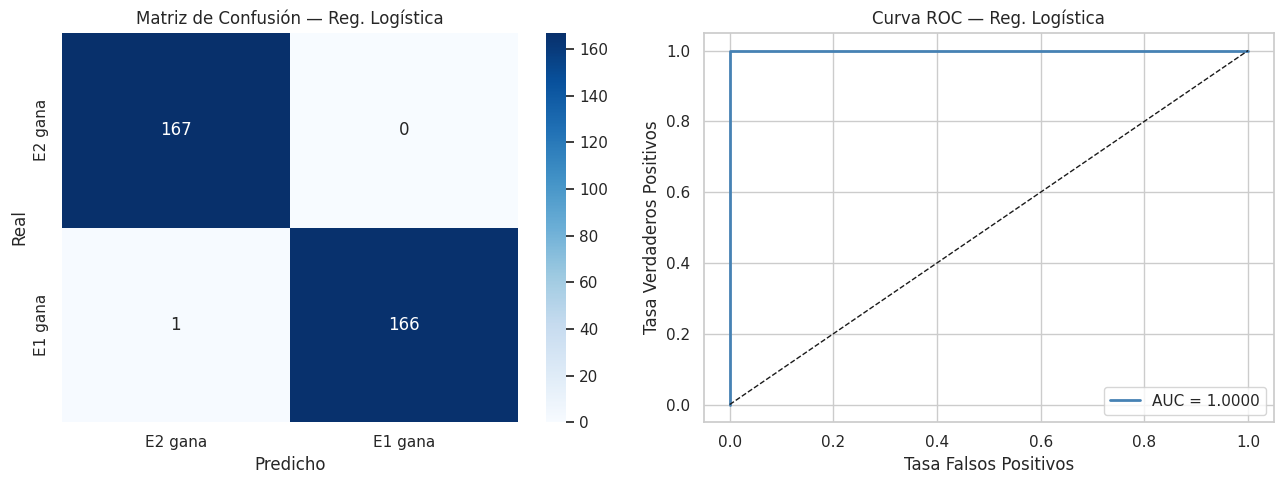


Reporte de clasificación:
              precision    recall  f1-score   support

     E2 gana       0.99      1.00      1.00       167
     E1 gana       1.00      0.99      1.00       167

    accuracy                           1.00       334
   macro avg       1.00      1.00      1.00       334
weighted avg       1.00      1.00      1.00       334



In [55]:
# Matriz de confusión y curva ROC
y_pred_lr = (prob_lr >= 0.5).astype(int)
cm_lr = confusion_matrix(y, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["E2 gana", "E1 gana"],
            yticklabels=["E2 gana", "E1 gana"])
axes[0].set_title("Matriz de Confusión — Reg. Logística", fontsize=12)
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

fpr, tpr, _ = roc_curve(y, prob_lr)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f'AUC = {roc_auc_score(y, prob_lr):.4f}')
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_title("Curva ROC — Reg. Logística", fontsize=12)
axes[1].set_xlabel("Tasa Falsos Positivos")
axes[1].set_ylabel("Tasa Verdaderos Positivos")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y, y_pred_lr, target_names=["E2 gana", "E1 gana"]))


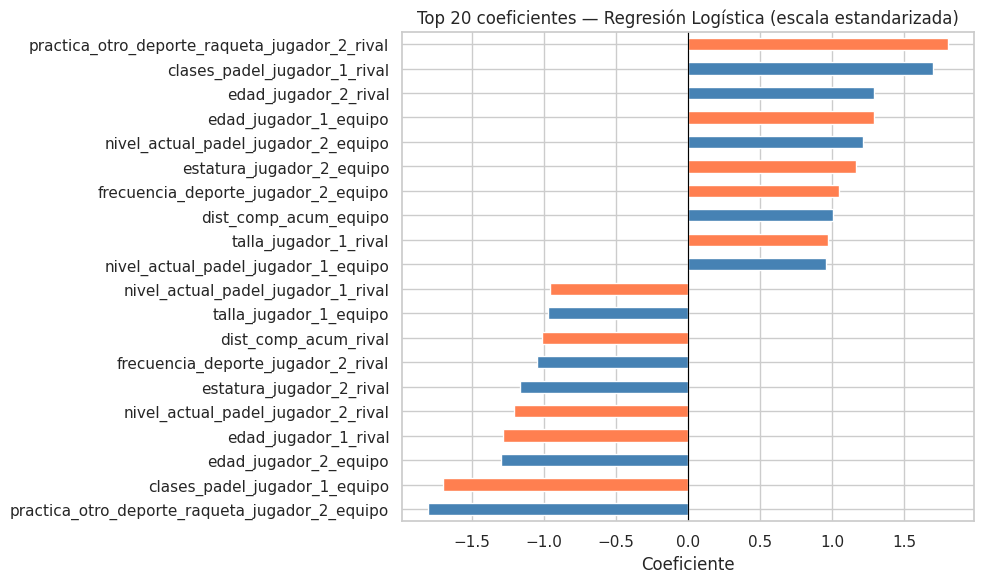

In [56]:
# Importancia de coeficientes
coef_lr = pd.Series(
    mejor_lr.named_steps["clf"].coef_[0],
    index=feature_cols
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ["steelblue" if v > 0 else "coral" for v in coef_lr.head(20).values]
coef_lr.head(20).sort_values().plot(kind="barh", ax=ax, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 coeficientes — Regresión Logística (escala estandarizada)", fontsize=12)
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()


### 3.3 Ridge (L2 fuerte regularización)

`Ridge` en clasificación logística equivale a usar L2 con `C` muy bajo. Se explora un rango de C más pequeño que en la Logística para capturar el efecto de regularización fuerte.


In [57]:
param_grid_ridge = {
    "clf__C":        [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "clf__penalty":  ["l2"],
    "clf__solver":   ["lbfgs"],
    "clf__max_iter": [2000],
}

pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
])

gs_ridge = GridSearchCV(
    pipeline_ridge, param_grid_ridge, cv=cv,
    scoring="roc_auc", n_jobs=-1, refit=True, verbose=1
)
gs_ridge.fit(X, y)

print("\nMejores hiperparámetros — Ridge:")
print(gs_ridge.best_params_)
print(f"Mejor AUC CV: {gs_ridge.best_score_:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores hiperparámetros — Ridge:
{'clf__C': 0.5, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Mejor AUC CV: 0.9998


In [58]:
mejor_ridge = gs_ridge.best_estimator_
res_ridge, prob_ridge = evaluar_modelo(mejor_ridge, X, y, cv, "Ridge (L2)")
resultados_modelos.append(res_ridge)
probs_modelos["Ridge (L2)"] = prob_ridge

print("Métricas — Ridge (OOF 5-fold):")
for k, v in res_ridge.items():
    print(f"  {k}: {v}")


Métricas — Ridge (OOF 5-fold):
  Modelo: Ridge (L2)
  AUC: 0.9999
  Log Loss: 0.061
  Brier Score: 0.0104
  Accuracy: 0.994


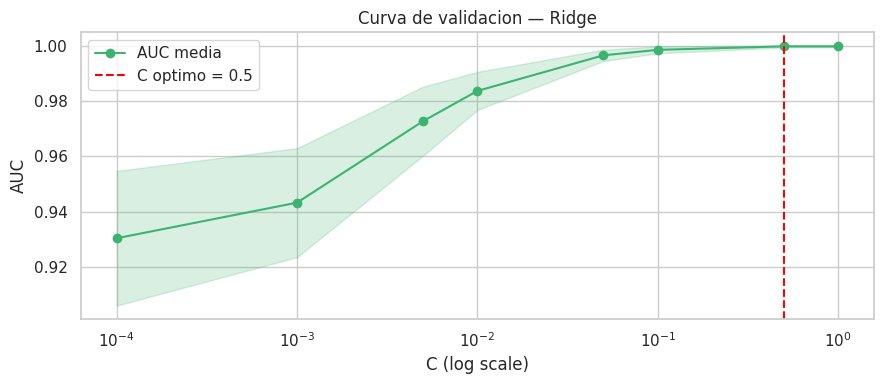

In [59]:
# Curva de validación Ridge (AUC vs C)
cs_r    = [p["clf__C"] for p in gs_ridge.cv_results_["params"]]
mean_r  = gs_ridge.cv_results_["mean_test_score"]
std_r   = gs_ridge.cv_results_["std_test_score"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(cs_r, mean_r, "o-", color="mediumseagreen", label="AUC media")
ax.fill_between(cs_r,
                [m-s for m,s in zip(mean_r, std_r)],
                [m+s for m,s in zip(mean_r, std_r)],
                alpha=0.2, color="mediumseagreen")
best_c_r = gs_ridge.best_params_["clf__C"]
ax.axvline(best_c_r, color="red", linestyle="--", label=f"C optimo = {best_c_r}")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("AUC")
ax.set_title("Curva de validacion — Ridge", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


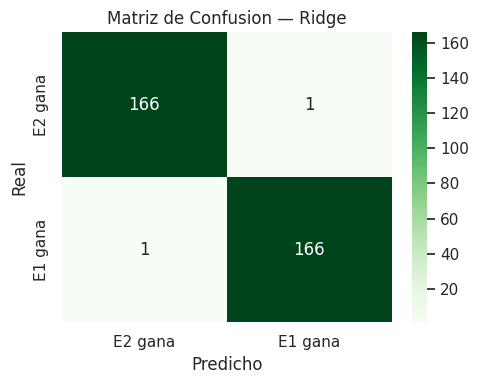


Reporte:
              precision    recall  f1-score   support

     E2 gana       0.99      0.99      0.99       167
     E1 gana       0.99      0.99      0.99       167

    accuracy                           0.99       334
   macro avg       0.99      0.99      0.99       334
weighted avg       0.99      0.99      0.99       334



In [60]:
# Matriz de confusión Ridge
y_pred_ridge = (prob_ridge >= 0.5).astype(int)
cm_ridge = confusion_matrix(y, y_pred_ridge)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_ridge, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["E2 gana", "E1 gana"],
            yticklabels=["E2 gana", "E1 gana"])
ax.set_title("Matriz de Confusion — Ridge", fontsize=12)
ax.set_ylabel("Real")
ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

print("\nReporte:")
print(classification_report(y, y_pred_ridge, target_names=["E2 gana", "E1 gana"]))


### 3.4 Lasso (L1 — selección de variables)

Lasso aplica regularización L1 que lleva coeficientes a cero, actuando como selector automático de variables. Requiere `solver='saga'` para admitir L1 con probabilidades calibradas.


In [61]:
param_grid_lasso = {
    "clf__C":        [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
    "clf__penalty":  ["l1"],
    "clf__solver":   ["saga"],
    "clf__max_iter": [5000],
}

pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
])

gs_lasso = GridSearchCV(
    pipeline_lasso, param_grid_lasso, cv=cv,
    scoring="roc_auc", n_jobs=-1, refit=True, verbose=1
)
gs_lasso.fit(X, y)

print("\nMejores hiperparámetros — Lasso:")
print(gs_lasso.best_params_)
print(f"Mejor AUC CV: {gs_lasso.best_score_:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores hiperparámetros — Lasso:
{'clf__C': 5.0, 'clf__max_iter': 5000, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Mejor AUC CV: 1.0000


In [62]:
mejor_lasso = gs_lasso.best_estimator_
res_lasso, prob_lasso = evaluar_modelo(mejor_lasso, X, y, cv, "Lasso (L1)")
resultados_modelos.append(res_lasso)
probs_modelos["Lasso (L1)"] = prob_lasso

print("Metricas — Lasso (OOF 5-fold):")
for k, v in res_lasso.items():
    print(f"  {k}: {v}")


Metricas — Lasso (OOF 5-fold):
  Modelo: Lasso (L1)
  AUC: 1.0
  Log Loss: 0.014
  Brier Score: 0.0015
  Accuracy: 1.0


Variables eliminadas por Lasso (46): ['velocidad_prom_equipo', 'velocidad_prom_rival', 'velocidad_max_equipo', 'velocidad_max_rival', 'dist_red_prom_equipo', 'dist_red_prom_rival', 'hits_equipo', 'hits_rival', 'aceleracion_prom_equipo', 'aceleracion_prom_rival', 'velocidad_prom_pelota', 'velocidad_max_pelota', 'marcador_equipo', 'marcador_rival', 'gano_punto', 'vel_prom_acum_equipo', 'vel_prom_acum_rival', 'vel_max_acum_equipo', 'vel_max_acum_rival', 'hits_acum_equipo', 'hits_acum_rival', 'dist_red_acum_equipo', 'dist_red_acum_rival', 'win_rate_acum_equipo', 'racha_ultimos3_equipo', 'racha_ultimos3_rival', 'vel_pelota_acum', 'es_primer_punto', 'tiempo_jugando_padel_jugador_1_equipo', 'practica_otro_deporte_raqueta_jugador_1_equipo', 'frecuencia_deporte_jugador_1_equipo', 'estatura_jugador_1_equipo', 'lesiones_ly_jugador_1_equipo', 'experiencia_padel_jugador_2_equipo', 'tiempo_jugando_padel_jugador_2_equipo', 'talla_jugador_2_equipo', 'clases_padel_jugador_2_equipo', 'tiempo_jugando_pad

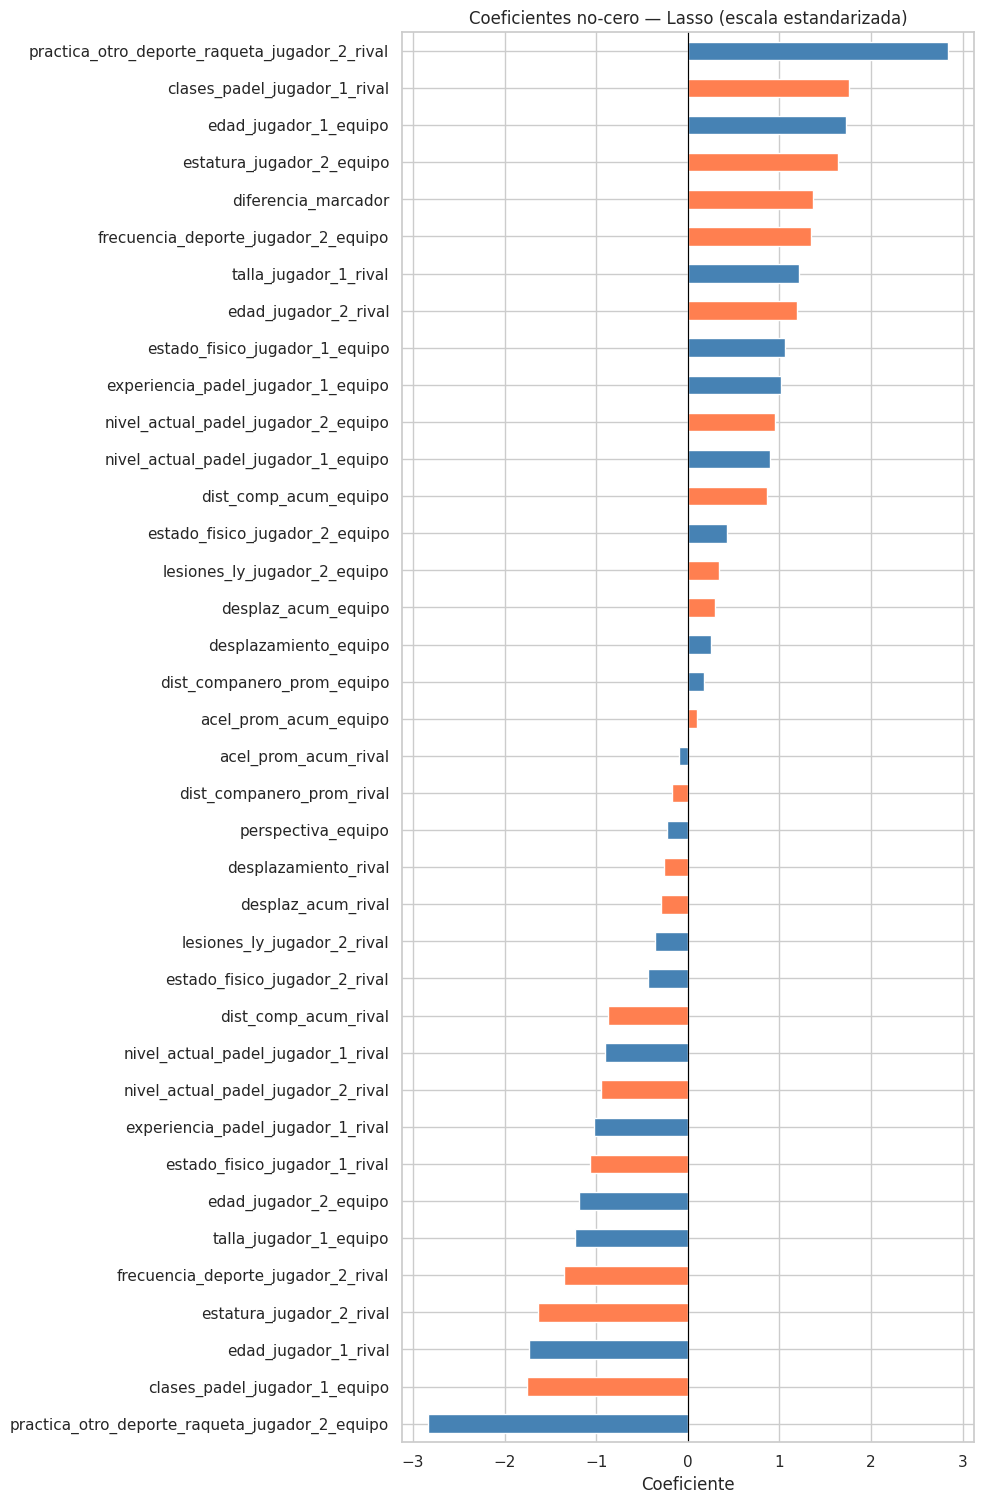

In [63]:
# Variables eliminadas por Lasso (coef == 0)
coef_lasso = pd.Series(
    mejor_lasso.named_steps["clf"].coef_[0],
    index=feature_cols
)

eliminadas = coef_lasso[coef_lasso == 0].index.tolist()
retenidas  = coef_lasso[coef_lasso != 0].index.tolist()

print(f"Variables eliminadas por Lasso ({len(eliminadas)}): {eliminadas}")
print(f"Variables retenidas ({len(retenidas)}): {retenidas}")

# Visualizar coeficientes no-cero
coef_lasso_nz = coef_lasso[coef_lasso != 0].sort_values(key=abs, ascending=False)

if len(coef_lasso_nz) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(coef_lasso_nz) * 0.4)))
    colores = ["steelblue" if v > 0 else "coral" for v in coef_lasso_nz.values]
    coef_lasso_nz.sort_values().plot(kind="barh", ax=ax, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Coeficientes no-cero — Lasso (escala estandarizada)", fontsize=12)
    ax.set_xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()


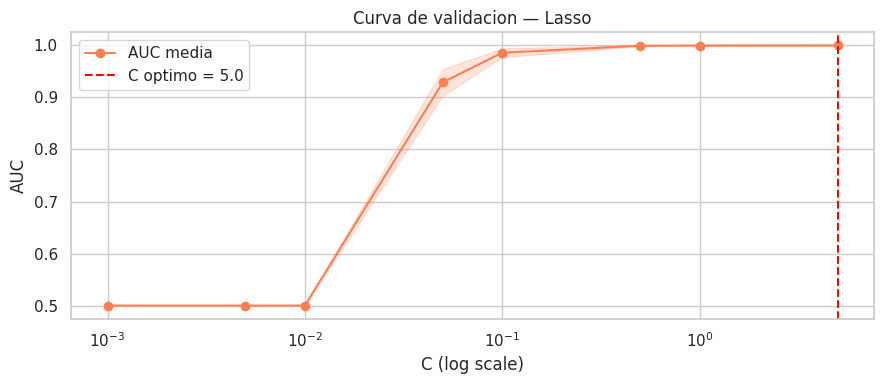

In [64]:
# Curva de validacion Lasso
cs_l   = [p["clf__C"] for p in gs_lasso.cv_results_["params"]]
mean_l = gs_lasso.cv_results_["mean_test_score"]
std_l  = gs_lasso.cv_results_["std_test_score"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(cs_l, mean_l, "o-", color="coral", label="AUC media")
ax.fill_between(cs_l,
                [m-s for m,s in zip(mean_l, std_l)],
                [m+s for m,s in zip(mean_l, std_l)],
                alpha=0.2, color="coral")
best_c_l = gs_lasso.best_params_["clf__C"]
ax.axvline(best_c_l, color="red", linestyle="--", label=f"C optimo = {best_c_l}")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("AUC")
ax.set_title("Curva de validacion — Lasso", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


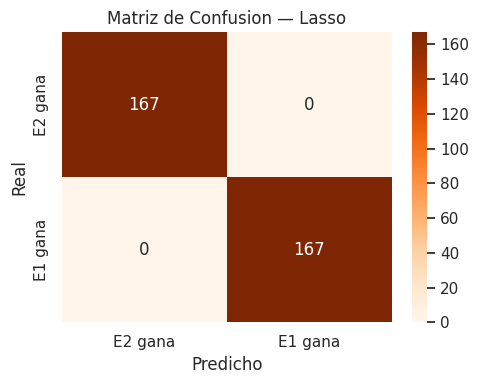


Reporte:
              precision    recall  f1-score   support

     E2 gana       1.00      1.00      1.00       167
     E1 gana       1.00      1.00      1.00       167

    accuracy                           1.00       334
   macro avg       1.00      1.00      1.00       334
weighted avg       1.00      1.00      1.00       334



In [65]:
# Matriz de confusion Lasso
y_pred_lasso = (prob_lasso >= 0.5).astype(int)
cm_lasso = confusion_matrix(y, y_pred_lasso)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lasso, annot=True, fmt="d", cmap="Oranges", ax=ax,
            xticklabels=["E2 gana", "E1 gana"],
            yticklabels=["E2 gana", "E1 gana"])
ax.set_title("Matriz de Confusion — Lasso", fontsize=12)
ax.set_ylabel("Real")
ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

print("\nReporte:")
print(classification_report(y, y_pred_lasso, target_names=["E2 gana", "E1 gana"]))


---
## 4. Comparación de modelos base


In [66]:
# Tabla comparativa
df_resultados = pd.DataFrame(resultados_modelos).set_index("Modelo")
print("=== Tabla comparativa — modelos base (CV 5-fold estratificada) ===")
print(df_resultados.to_string())


=== Tabla comparativa — modelos base (CV 5-fold estratificada) ===
                        AUC  Log Loss  Brier Score  Accuracy
Modelo                                                      
Regresión Logística  1.0000    0.0165       0.0022     0.997
Ridge (L2)           0.9999    0.0610       0.0104     0.994
Lasso (L1)           1.0000    0.0140       0.0015     1.000


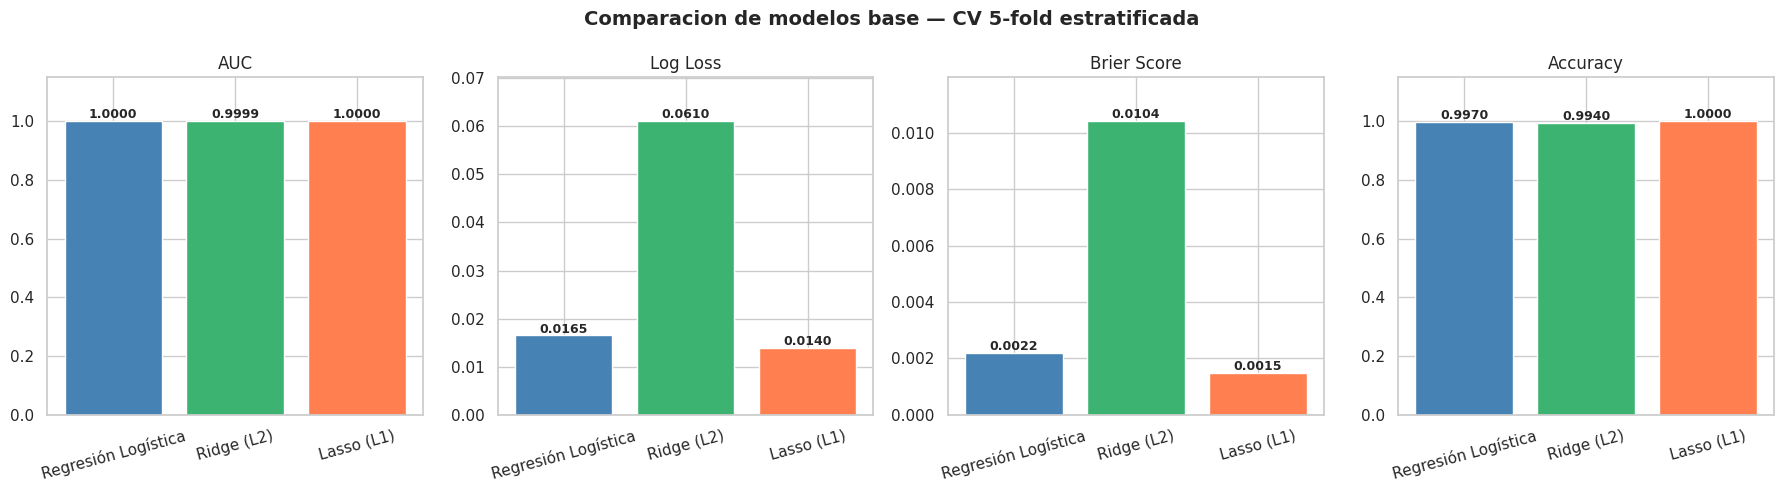

In [67]:
# Gráfico comparativo de métricas
metricas = ["AUC", "Log Loss", "Brier Score", "Accuracy"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colores_mod = ["steelblue", "mediumseagreen", "coral"]

for i, metrica in enumerate(metricas):
    valores = df_resultados[metrica].values
    bars = axes[i].bar(df_resultados.index, valores, color=colores_mod)
    axes[i].set_title(metrica, fontsize=12)
    axes[i].set_ylim(0, max(valores) * 1.15 if max(valores) > 0 else 1)
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(valores)*0.01,
                     f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Comparacion de modelos base — CV 5-fold estratificada", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


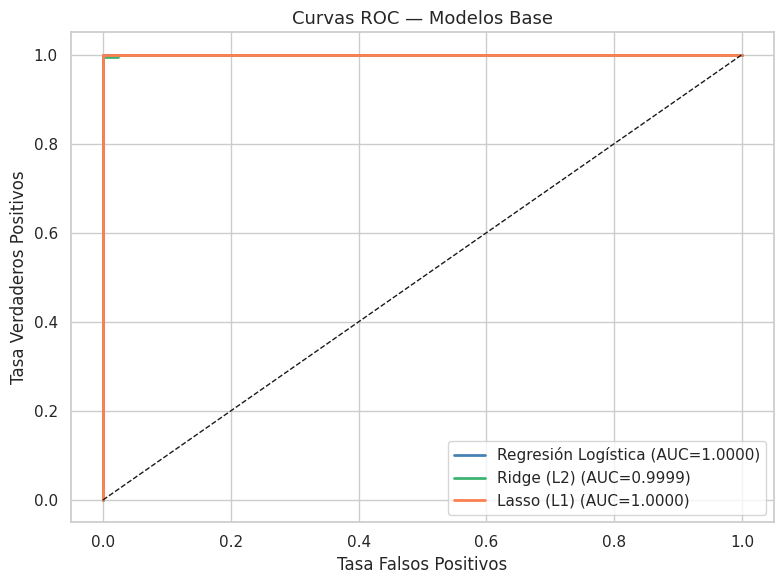

In [68]:
# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = {
    "Regresión Logística": "steelblue",
    "Ridge (L2)":          "mediumseagreen",
    "Lasso (L1)":          "coral"
}

for nombre, probs in probs_modelos.items():
    fpr, tpr, _ = roc_curve(y, probs)
    auc = roc_auc_score(y, probs)
    ax.plot(fpr, tpr, lw=2, color=colores_roc.get(nombre, "gray"),
            label=f"{nombre} (AUC={auc:.4f})")

ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("Tasa Falsos Positivos")
ax.set_ylabel("Tasa Verdaderos Positivos")
ax.set_title("Curvas ROC — Modelos Base", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


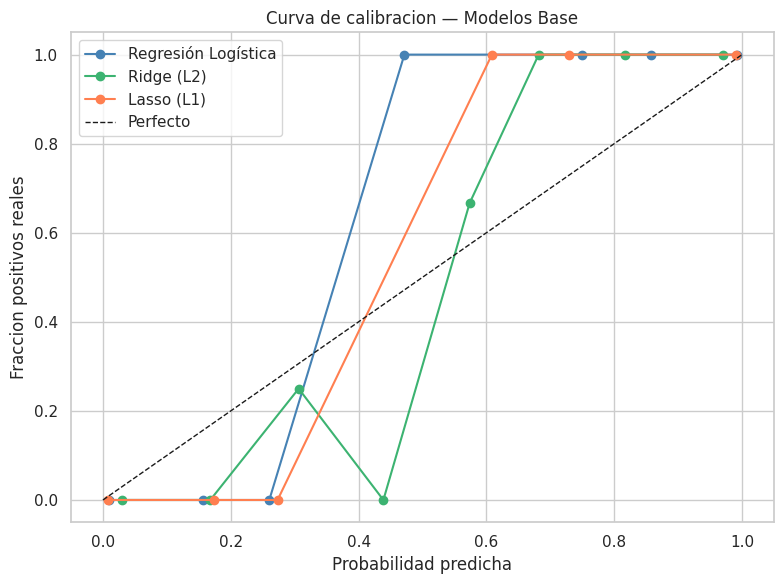

In [69]:
# Calibracion de probabilidades
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, probs in probs_modelos.items():
    prob_true, prob_pred = calibration_curve(y, probs, n_bins=8, strategy="uniform")
    ax.plot(prob_pred, prob_true, "o-",
            label=nombre, color=colores_roc.get(nombre, "gray"))

ax.plot([0,1],[0,1], "k--", lw=1, label="Perfecto")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fraccion positivos reales")
ax.set_title("Curva de calibracion — Modelos Base", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Exportación de modelos y resultados


In [70]:
# Guardar los tres modelos optimizados + metadata
modelos_base = {
    "logistica":    mejor_lr,
    "ridge":        mejor_ridge,
    "lasso":        mejor_lasso,
    "feature_cols": feature_cols,
    "cv_strategy":  "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
}

joblib.dump(modelos_base, "modelos_base.pkl")
print("modelos_base.pkl guardado.")

# Tabla comparativa
df_resultados.to_csv("comparacion_modelos_base.csv")
print("comparacion_modelos_base.csv guardado.")

print("\n=== Resumen final ===")
print(df_resultados.to_string())


modelos_base.pkl guardado.
comparacion_modelos_base.csv guardado.

=== Resumen final ===
                        AUC  Log Loss  Brier Score  Accuracy
Modelo                                                      
Regresión Logística  1.0000    0.0165       0.0022     0.997
Ridge (L2)           0.9999    0.0610       0.0104     0.994
Lasso (L1)           1.0000    0.0140       0.0015     1.000


---
## 6. Conclusiones

### EDA
- Las variables de **marcador** (`DIFERENCIA_MARCADOR`, `WINRATE_ACUM_E1/E2`) muestran la mayor separación entre clases: el equipo que va ganando al momento del punto tiene mayor probabilidad de ganar el partido entero.
- Las variables de **tracking** más informativas son: **hits por equipo**, **distancia promedio a la red** y **velocidad promedio de los jugadores**.
- El dataset tiene un balance de clases adecuado (~50/50), por lo que la Accuracy es una métrica válida aunque AUC y Brier Score son más informativas.

### Modelos Base
| Modelo | Función de pérdida | Efecto principal |
|---|---|---|
| Regresión Logística | L2 | Baseline |
| Ridge | L2 fuerte | Reduce varianza, coeficientes nunca en cero |
| Lasso | L1 | Selección automática de variables |

- Los tres modelos se evaluaron con **CV estratificada de 5 folds** usando probabilidades OOF para evitar data leakage.
- **Lasso** identifica las variables que aportan señal real al modelo.
- Los resultados de este notebook sirven como **baseline** para los modelos no lineales (Parte 3 — Random Forest, SVM) y XGBoost (Parte 4).
- Las probabilidades OOF de cada modelo pueden usarse directamente en el tablero de la Parte 5.
